# Distances and ordination

**R equivalent:** `distance()`, `UniFrac()`, `ordinate()`, `plot_ordination()`

This notebook reproduces the classic phyloseq ordination workflow on the
GlobalPatterns dataset.

In [8]:
import numpy as np

from pyloseq import (
    OtuTable,
    Phyloseq,
    PhyTree,
    SampleData,
    TaxTable,
    distance_method_list,
    plot_ordination,
)
from pyloseq.datasets.fixtures import load_global_patterns_reference

ref = load_global_patterns_reference()
gp = Phyloseq(
    otu=OtuTable(ref["otu_table"], taxa_are_rows=True),
    sam=SampleData(ref["sample_data"]),
    tax=TaxTable(ref["tax_table"]),
    tree=PhyTree.from_newick(ref["phy_tree_newick"]),
)
print(gp)

Phyloseq(19216 taxa × 26 samples)
  sample_data: 7 variables
  tax_table:   7 ranks
  phy_tree:    19216 tips


## Available distance methods

In [9]:
methods = distance_method_list()
for group, names in methods.items():
    print(f"{group}: {names}")

phylogenetic: ['dpcoa', 'unifrac', 'wunifrac']
information: ['jsd']
vegan-equivalent: ['binary', 'bray', 'canberra', 'correlation', 'cosine', 'euclidean', 'jaccard', 'manhattan', 'maximum', 'minkowski', 'sorensen']


## Bray-Curtis dissimilarity

**R equivalent:** `distance(gp, "bray")`

In [10]:
dm_bray = gp.distance("bray")
print(f"Distance matrix: {len(dm_bray.ids)} × {len(dm_bray.ids)}")
print(f"Min non-zero: {np.array(dm_bray.data)[np.array(dm_bray.data) > 0].min():.4f}")
print(f"Max:          {np.array(dm_bray.data).max():.4f}")

# Sanity: zero diagonal, symmetric
arr = np.array(dm_bray.data)
assert np.allclose(np.diag(arr), 0), "Diagonal must be zero"
assert np.allclose(arr, arr.T), "Distance matrix must be symmetric"

Distance matrix: 26 × 26
Min non-zero: 0.0875
Max:          0.9986


## PCoA on Bray-Curtis

**R equivalent:** `ordinate(gp, "PCoA", "bray")`

In [11]:
pcoa_result = gp.ordinate("PCoA", distance="bray", number_of_dimensions=2)
prop_exp = pcoa_result.proportion_explained
print(f"Axis 1 explains {prop_exp.iloc[0]*100:.1f}% of variance")
print(f"Axis 2 explains {prop_exp.iloc[1]*100:.1f}% of variance")

# Python result: Axis.1 ~14%, Axis.2 ~11% on GlobalPatterns Bray-Curtis (raw counts)
assert prop_exp.iloc[0] > 0.10, "Axis 1 should explain > 10% of variance"
assert prop_exp.iloc[1] > 0.08, "Axis 2 should explain > 8% of variance"

Axis 1 explains 13.9% of variance
Axis 2 explains 10.9% of variance


## Plot the ordination

**R equivalent:** `plot_ordination(gp, pcoa_result, color="SampleType")`

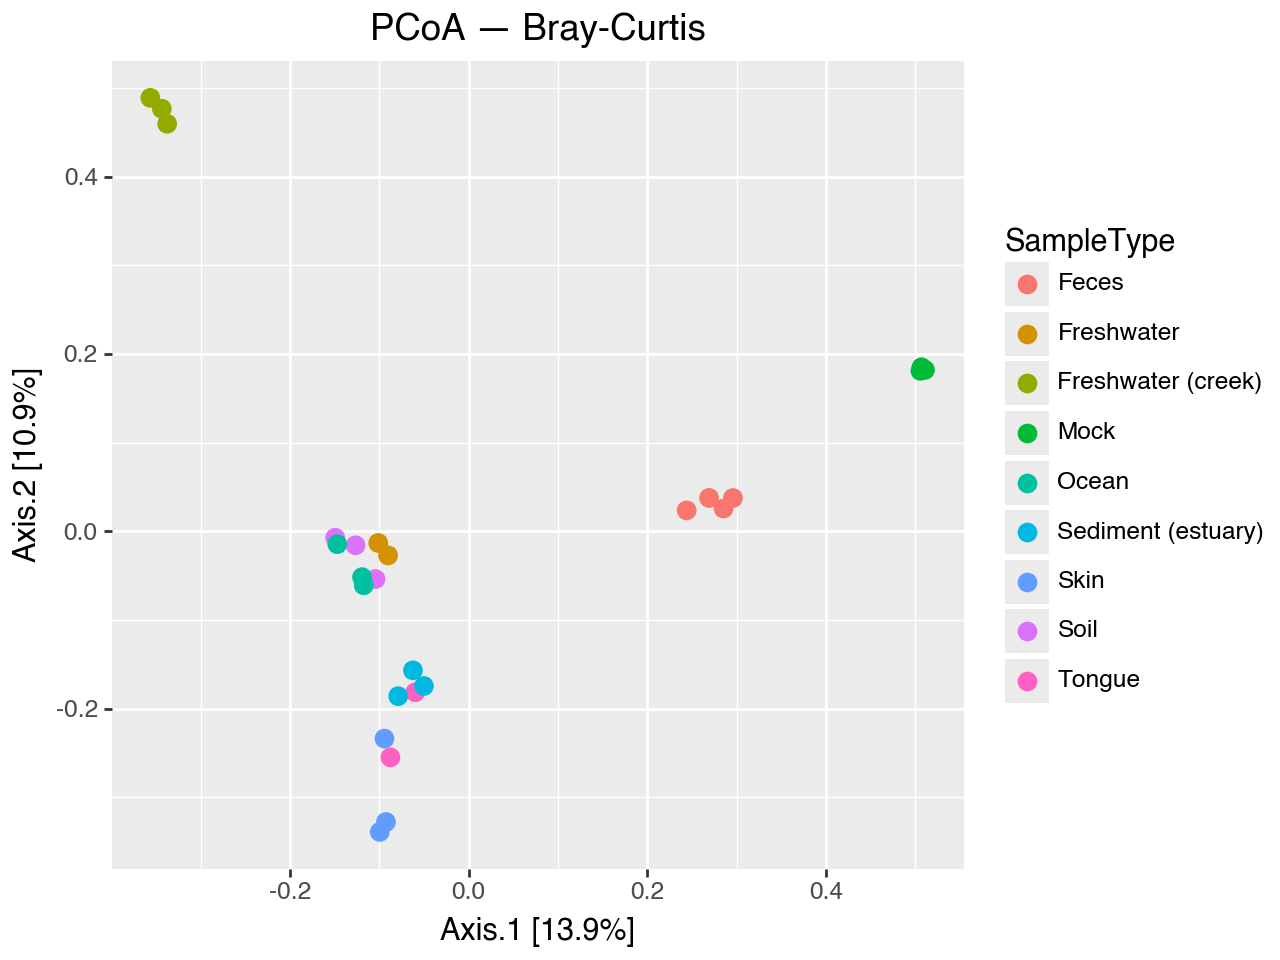

In [13]:
p = plot_ordination(gp, pcoa_result, color="SampleType", title="PCoA — Bray-Curtis")
display(p)

## PERMANOVA one-liner

Distance matrices are `skbio.DistanceMatrix` objects — plug directly into
`skbio.stats.distance.permanova` without any conversion.

**R equivalent:** `vegan::adonis2(dist ~ SampleType, data=sample_data(gp))`

In [14]:
from skbio.stats.distance import permanova

grouping = gp.sample_data.to_frame()["SampleType"]
result = permanova(gp.distance("bray"), grouping, permutations=99)
print(result)
assert result["p-value"] is not None, "permanova should return a p-value"

method name               PERMANOVA
test statistic name        pseudo-F
sample size                      26
number of groups                  9
test statistic             4.425944
p-value                        0.01
number of permutations           99
Name: PERMANOVA results, dtype: object


## Unweighted UniFrac

**R equivalent:** `UniFrac(gp, weighted=FALSE)`

In [15]:
from pyloseq import unifrac

dm_uf = unifrac(gp, weighted=False)
print(f"UniFrac matrix: {len(dm_uf.ids)} × {len(dm_uf.ids)}")

# UniFrac values are in [0, 1]
arr_uf = np.array(dm_uf.data)
assert arr_uf.min() >= 0
assert arr_uf.max() <= 1
print(f"Range: [{arr_uf[arr_uf > 0].min():.4f}, {arr_uf.max():.4f}]")

UniFrac matrix: 26 × 26
Range: [0.2545, 0.7867]
